This file is meant to show how to test changes to the noisy gates library downloaded in this folder offline

As well as be a Quick-start guide

get API key here: ```https://cloud.ibm.com/iam/apikeys```



In [1]:
# Standard libraries
import numpy as np
import json
import os, sys, importlib
from typing import List
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# Qiskit
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.controlflow import ControlFlowOp
from qiskit.result import marginal_counts
from qiskit.transpiler import CouplingMap, Layout
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit_ibm_runtime.fake_provider import FakeBrisbane
  # try other Fake*V2 if needed

# Point to the *parent* of the package folder
LOCAL_QG_PATH = r"..\src"   # or r"C:\path\to\your\local\quantum-gates\src"
LOCAL_QG_PATH = os.path.abspath(LOCAL_QG_PATH)

# Put local src at the very front of sys.path
if LOCAL_QG_PATH in sys.path:
    sys.path.remove(LOCAL_QG_PATH)
sys.path.insert(0, LOCAL_QG_PATH)

# Purge any cached copies of the package
for m in list(sys.modules):
    if m == "quantum_gates" or m.startswith("quantum_gates."):
        del sys.modules[m]

# Invalidate import caches and import the local package
importlib.invalidate_caches()
import quantum_gates
from quantum_gates.utilities import DeviceParameters

print("Using quantum_gates from:", quantum_gates.__file__)

# Own library
from quantum_gates.utilities import fix_counts
from quantum_gates.simulators import MrAndersonSimulator
from quantum_gates.gates import standard_gates
from quantum_gates.circuits import EfficientCircuit, BinaryCircuit, Circuit
from quantum_gates.utilities import DeviceParameters
from quantum_gates.utilities import setup_backend
# for reordering statevectors
from quantum_gates._utility.simulations_utility import sv_normal_to_qiskit, sv_qiskit_to_normal
from quantum_gates._utility.simulations_utility import extract_qubit_orders, permute_qiskit_sv_to_logical, permute_normal_sv_to_logical_normal

    

Using quantum_gates from: c:\Users\npace\Desktop\quantum-gates\src\quantum_gates\__init__.py


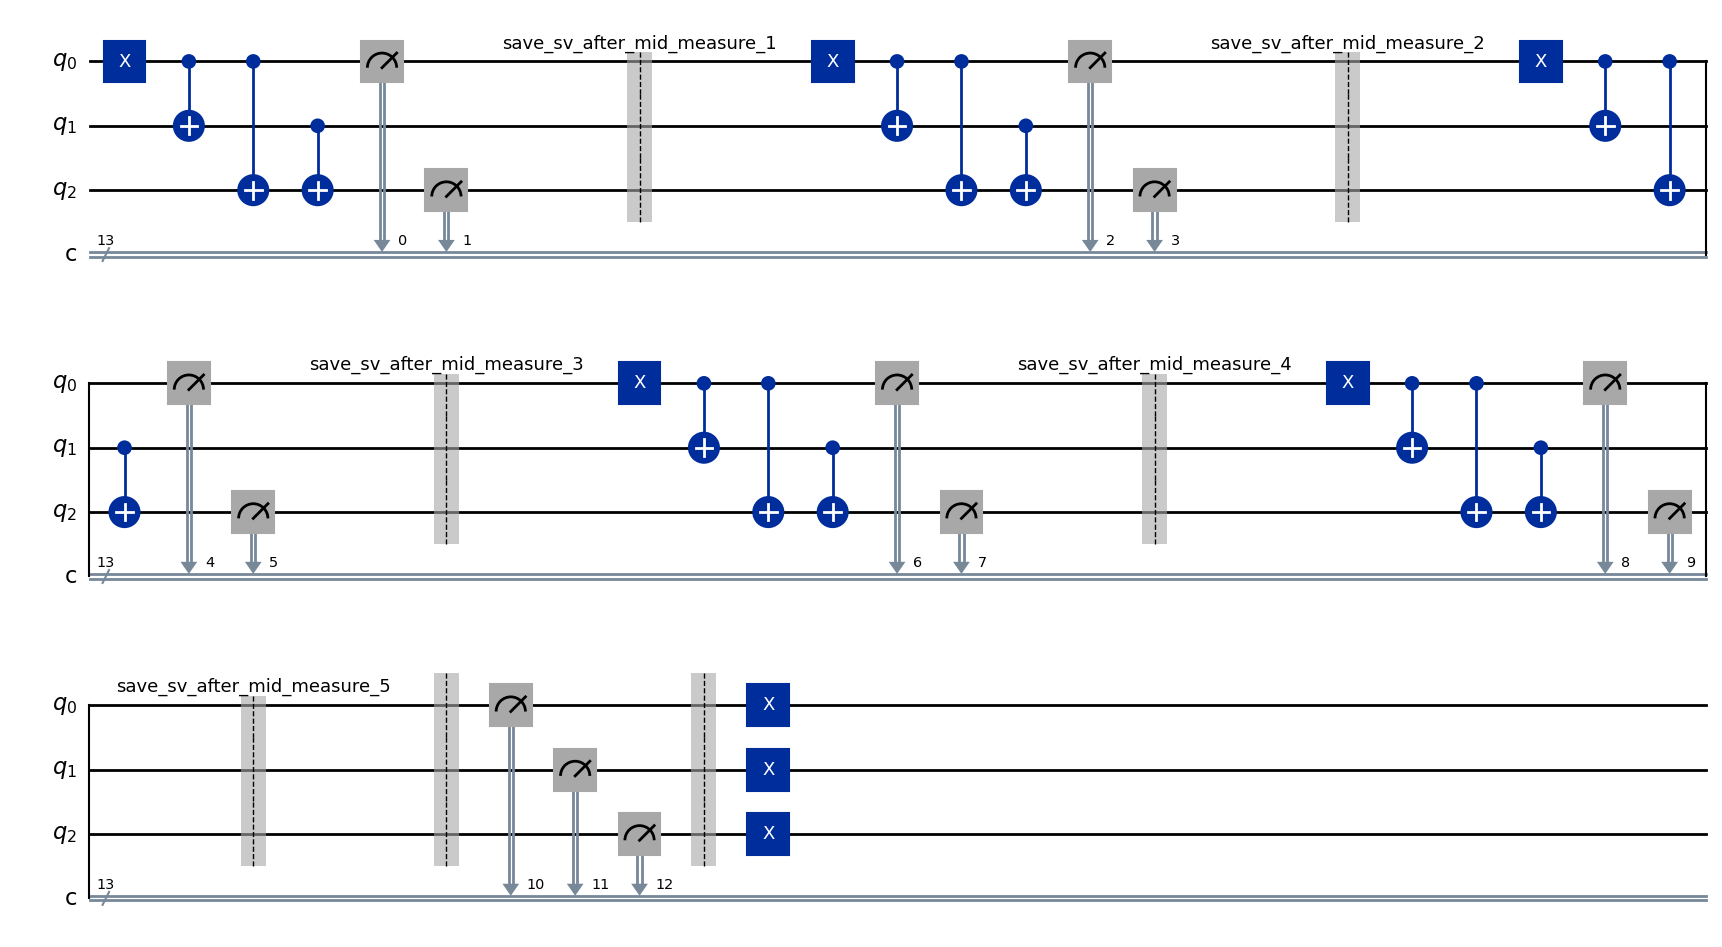

In [2]:
# PERMUTATION CIRCUIT EXAMPLE 

def build_circuit(cycles, N_q=3, extra_measures=2, bit_per_mid_measure=2, AER_boolean=False):
    N_m = N_q + extra_measures
    
    qc = QuantumCircuit(N_q, N_m)

    for c in range(1, cycles+1):

        # Prepare |01>
        qc.x(0)
        qc.cx(0,1)
        
        #qc.save_statevector(label=f"sv_after_entanglement_{c}")
        qc.cx(0,2)
        #qc.save_statevector(label=f"sv_after_cx02_{c}")
        qc.cx(1,2)
        #qc.save_statevector(label=f"sv_after_cx12_{c}")

        # Mid-cycle measurement
        # Classical bits reserved for this cycle
        cl_start = (c-1) * bit_per_mid_measure
        cl_end   = c * bit_per_mid_measure
        clbits   = list(range(cl_start, cl_end))

        # Mid-cycle measurement (each cycle writes to unique clbits)
        qc.measure([0, N_q-1], clbits)
        #qc.save_statevector(label=f"sv_after_mid_measure_{c}")
        if not AER_boolean:
            qc.barrier(label=f"save_sv_after_mid_measure_{c}")
        else:
            qc.save_statevector(label=f"save_sv_after_mid_measure_{c}")  #

        # Measure
        
    qc.barrier()  #
    qc.measure(range(N_q), range(extra_measures,N_m))
    qc.barrier()  #
    qc.x(range(N_q))  #
        

    return qc


cycles=5
bit_per_mid_measure=2
extra_measures= cycles * bit_per_mid_measure
N_q=3
N_m = N_q + extra_measures

qc = build_circuit(cycles=cycles, N_q=N_q, extra_measures=extra_measures, bit_per_mid_measure=bit_per_mid_measure)

qc.draw('mpl')

In [3]:
# call the Noisy simulator
#sim = MrAndersonSimulator(gates=standard_gates, CircuitClass=EfficientCircuit)

 
# For Noise free simulation
from quantum_gates.gates import NoiseFreeGates 

sim = MrAndersonSimulator(
    gates=NoiseFreeGates,        # <- ideal gates (no noise)
    CircuitClass=EfficientCircuit
)


bit_flip_bool = True # turn on/off for readout noise

initial_psi = np.zeros(2**N_q)
initial_psi[0] = 1.0  # set |00...0⟩
initial_layout = list(range(N_q))  # logical qubit 0→physical 0, 1→1, etc.

shots = 1

### To use a real backend from IBM Quantum, uncomment and set up the following:

### Here we use a Fake Backend for simplicity

In [4]:
# Pick a fake backend for device parameters
backend = FakeBrisbane()  # 127 qubits; change to another Fake*V2 if import fails

# 2) Use only N qubits
qubits_layout = list(range(N_q))

# 3) Load via YOUR class and save JSON next to the script
device_param = DeviceParameters(qubits_layout)
device_param.load_from_backend(backend)
device_param_lookup = device_param.__dict__()
#device_param.save_to_json("./")  # writes ./device_parameters.json
#print("Wrote ./device_parameters.json")

In [5]:
# Transpile circuit
needs_controlflow = any(isinstance(op.operation, ControlFlowOp) for op in qc.data)

t_circ = transpile(
    qc,
    backend,
    initial_layout=qubits_layout,
    seed_transpiler=42,
    **({} if needs_controlflow else {"scheduling_method": "asap"})
)

# Run simulation
res  = sim.run( 
    t_qiskit_circ=t_circ, 
    psi0=initial_psi, 
    shots=shots, 
    device_param=device_param_lookup,
    nqubit=N_q,
    bit_flip_bool=bit_flip_bool,
    )

# get results
probs = res["probs"]
results = res["results"]
num_clbits = res["num_clbits"]
barrier_statevectors = res["barrier_statevectors"]

mid_counts = res["mid_counts"]


#print("Mid-circuit measurement results", results)
print("Number of classical bits in circuit:", num_clbits)
print("Mid-circuit measurement counts:", mid_counts)

Number of classical bits in circuit: 13
Mid-circuit measurement counts: {'0110100011001': 1}


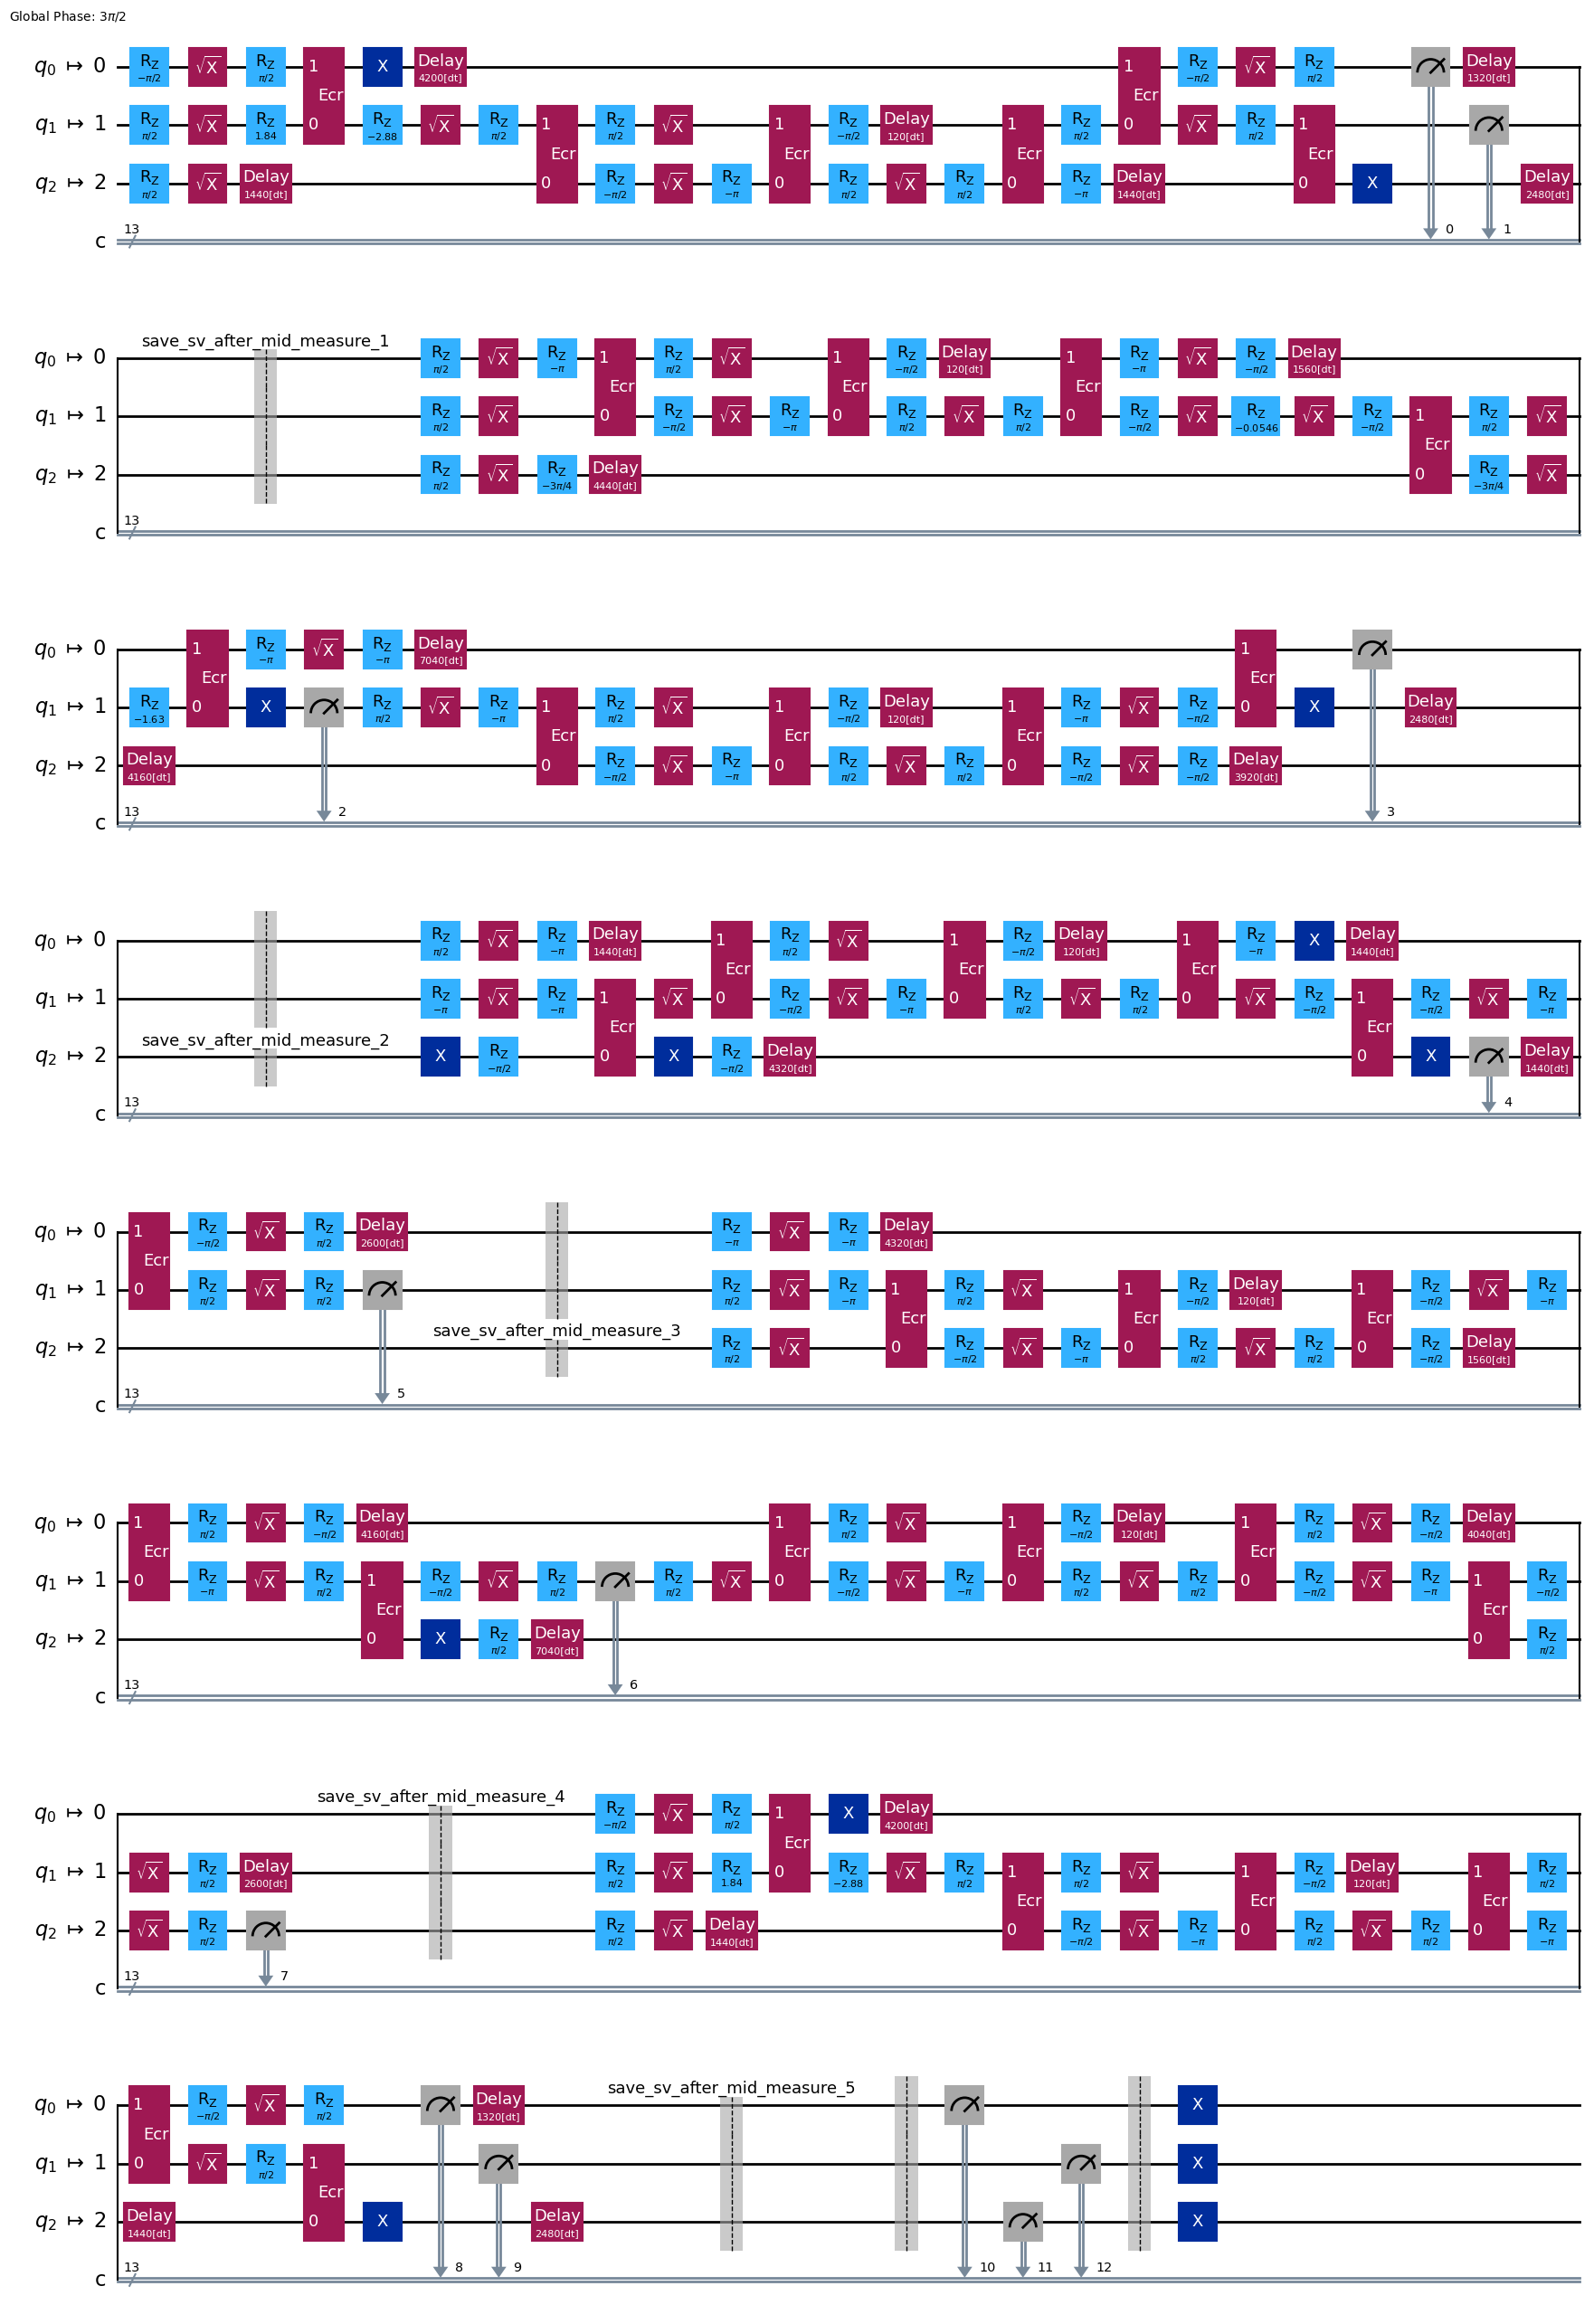

In [6]:
t_circ.draw('mpl')

In [7]:
def convert_barrier_statevectors_to_qiskit_order(barrier_statevectors):
    """
    Given barrier_statevectors structured as:
    [
        [
            (label, statevector_array),
            ...
        ],
        ...
    ]

    Returns the same structure but with each statevector converted
    to Qiskit ordering using sv_normal_to_qiskit.
    """
    converted = []
    for chunk in barrier_statevectors:
        new_chunk = []
        for label, sv in chunk:
            sv_qiskit = sv_normal_to_qiskit(sv)
            new_chunk.append((label, sv_qiskit))
        converted.append(new_chunk)
    return converted

In [8]:
barrier_SV_qiskit_style = convert_barrier_statevectors_to_qiskit_order(barrier_statevectors)

In [9]:
barrier_statevectors


[[('save_sv_after_mid_measure_1',
   array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
          -4.55342924e-16-1.90703785e-16j,  4.96867689e-01+8.67826307e-01j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j])),
  ('save_sv_after_mid_measure_2',
   array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
           1.88841054e-17+1.84508421e-17j, -6.47112461e-32+7.63278329e-17j,
          -8.39436680e-01-5.43457505e-01j, -5.55111512e-17-1.11022302e-16j])),
  ('save_sv_after_mid_measure_3',
   array([ 0.00000000e+00+0.00000000e+00j, -8.39436680e-01+5.43457505e-01j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j, -9.89070924e-16-2.17549248e-16j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+

In [10]:
barrier_SV_qiskit_style

[[('save_sv_after_mid_measure_1',
   array([ 0.00000000e+00+0.00000000e+00j, -4.55342924e-16-1.90703785e-16j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,  4.96867689e-01+8.67826307e-01j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j])),
  ('save_sv_after_mid_measure_2',
   array([ 0.00000000e+00+0.00000000e+00j,  1.88841054e-17+1.84508421e-17j,
           0.00000000e+00+0.00000000e+00j, -8.39436680e-01-5.43457505e-01j,
           0.00000000e+00+0.00000000e+00j, -6.47112461e-32+7.63278329e-17j,
           0.00000000e+00+0.00000000e+00j, -5.55111512e-17-1.11022302e-16j])),
  ('save_sv_after_mid_measure_3',
   array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
          -8.39436680e-01+5.43457505e-01j, -9.89070924e-16-2.17549248e-16j,
           0.00000000e+00+0.00000000e+00j,  0.00000000e+

In [11]:
trans_simulator_save_qubit_orders = extract_qubit_orders(t_circ, instruction_type="barrier")
print(trans_simulator_save_qubit_orders)

[('save_sv_after_mid_measure_1', [0, 2, 1]), ('save_sv_after_mid_measure_2', [2, 1, 0]), ('save_sv_after_mid_measure_3', [2, 0, 1]), ('save_sv_after_mid_measure_4', [0, 1, 2]), ('save_sv_after_mid_measure_5', [0, 2, 1])]


Post processing and plotting hists

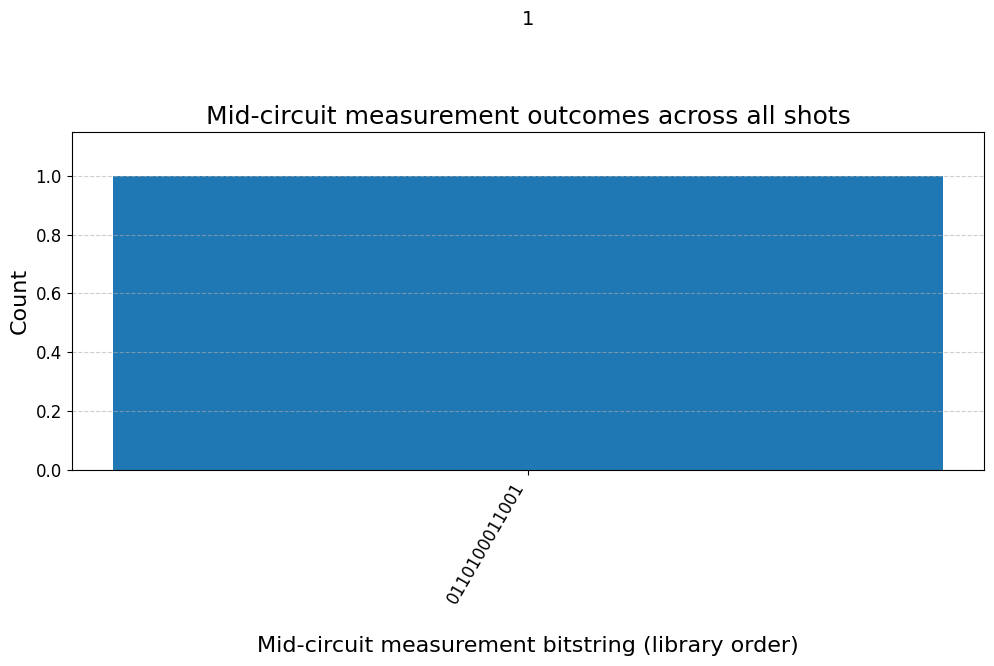

Mid-circuit measurement counts: {'0110100011001': 1}


In [12]:

# --- Plot histogram ---
labels = sorted(mid_counts.keys())
values = [mid_counts[k] for k in labels]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color="#1f77b4")  # same default Aer blue

# Extend y-axis a bit to fit annotations
max_val = max(values)
plt.ylim(0, max_val * 1.15)

# Annotate bar tops
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
             ha='center', va='bottom', fontsize=14, color="black")

plt.xlabel("\nMid-circuit measurement bitstring (library order)", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.title("Mid-circuit measurement outcomes across all shots",fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.yticks(fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=12)   # tilt x-axis labels

plt.show()

# --- Optional printout ---
print("Mid-circuit measurement counts:", dict(mid_counts))

Modified Hist Plot of above 5% counts 

Filtered mid-circuit measurement counts

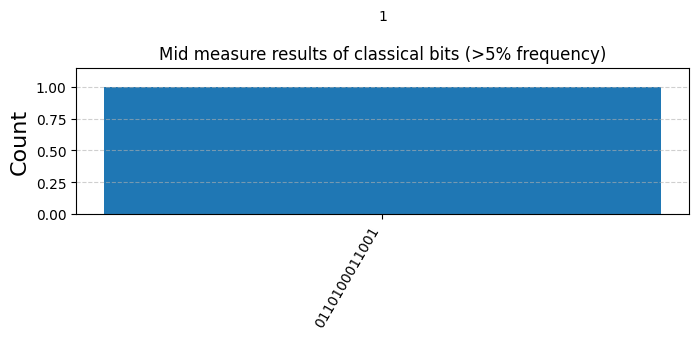

In [13]:
threshold = 0.05 * shots  # 5% cutoff

# --- Filter ---
filtered_counts = {k: v for k, v in mid_counts.items() if v >= threshold}

# --- Sort by bitstring (optional) ---
filtered_labels = list(sorted(filtered_counts.keys()))
filtered_values = [filtered_counts[k] for k in filtered_labels]

# --- Plot ---
plt.figure(figsize=(7, 4))
bars = plt.bar(filtered_labels, filtered_values, color="#1f77b4")  # same default Aer blue

# Extend y-axis a bit to fit annotations
max_val = max(filtered_values)
plt.ylim(0, max_val * 1.15)

# Annotate bar tops
for bar, val in zip(bars, filtered_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
             ha='center', va='bottom', fontsize=10, color="black")

# Match Aer-style axes
plt.ylabel("Count", fontsize=16)
plt.xlabel("")  # Aer histograms usually skip x-axis label
plt.title("Mid measure results of classical bits (>5% frequency)", fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Tight layout to match Aer formatting
plt.tight_layout()
plt.show()

Probabilities Generated by Final Measures

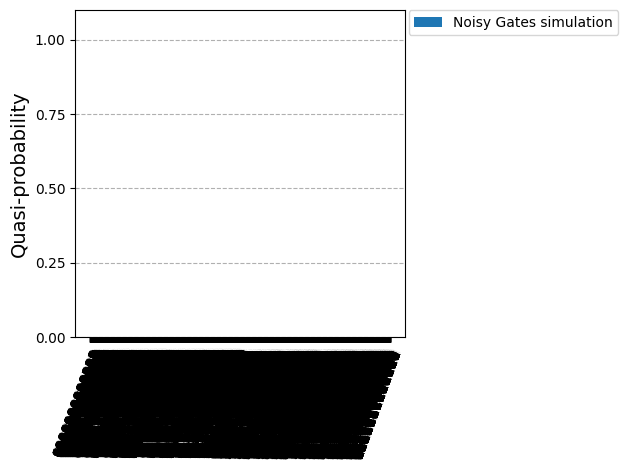

In [14]:
# Probabilities Generated by Final Measures
measured_qubit = N_m
counts_ng = fix_counts(probs, measured_qubit)
plot_histogram(counts_ng, bar_labels=False, legend=['Noisy Gates simulation'])

Comparison with AER

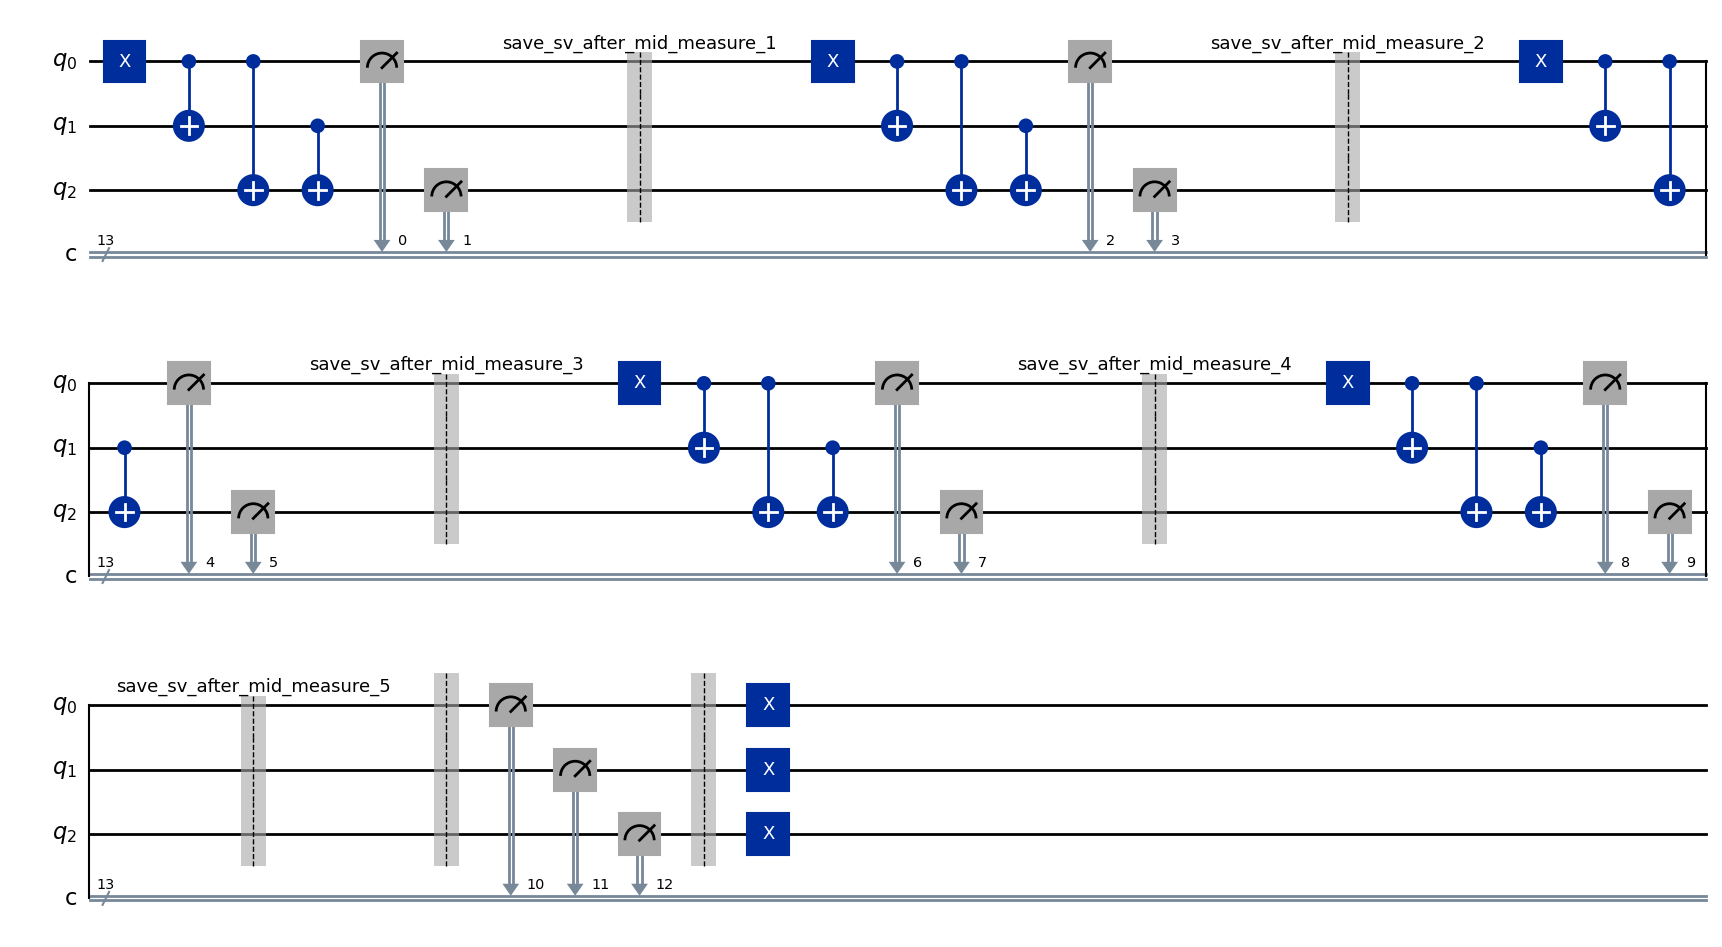

In [15]:
qc = build_circuit(cycles=cycles, N_q=N_q, extra_measures=extra_measures, bit_per_mid_measure=bit_per_mid_measure, AER_boolean=True)
qc.draw('mpl')


In [16]:
# Simulate with Aer
sim = AerSimulator()
t_qc = transpile(qc, sim)

result = sim.run(qc, shots=shots).result()
counts = result.get_counts()

In [17]:
Aer_svs = {}
for label in result.data().keys():
    Aer_svs[label] = result.data()[label]

In [18]:
Aer_svs

{'counts': {'0xd19': 1},
 'save_sv_after_mid_measure_1': Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j],
             dims=(2, 2, 2)),
 'save_sv_after_mid_measure_2': Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j,
              0.+0.j],
             dims=(2, 2, 2)),
 'save_sv_after_mid_measure_3': Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j],
             dims=(2, 2, 2)),
 'save_sv_after_mid_measure_4': Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j],
             dims=(2, 2, 2)),
 'save_sv_after_mid_measure_5': Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j],
             dims=(2, 2, 2))}

In [19]:
AER_trans_save_qubit_orders = extract_qubit_orders(t_qc, instruction_type="save_statevector")
print(AER_trans_save_qubit_orders)

[('save_sv_after_mid_measure_1', [0, 1, 2]), ('save_sv_after_mid_measure_2', [0, 1, 2]), ('save_sv_after_mid_measure_3', [0, 1, 2]), ('save_sv_after_mid_measure_4', [0, 1, 2]), ('save_sv_after_mid_measure_5', [0, 1, 2])]


## Before Permutations Show Testing SV Fidelity

In [20]:
from qiskit.quantum_info import state_fidelity
def compare_and_print(Aer_svs, barrier_SV_qiskit_style):

    flat_list = barrier_SV_qiskit_style[0]

    print("\n================ STATEVECTOR COMPARISON ================\n")

    for label, ours in flat_list:

        if label not in Aer_svs:
            print(f"WARNING: {label} missing from Aer_svs")
            continue

        aer = Aer_svs[label]        # Statevector object
        ours_arr = np.asarray(ours)  # np array

        fid = state_fidelity(aer, ours_arr)

        print(f"▶ {label}")
        print("AER statevector:")
        print(aer.data)

        print("\nOur statevector (Qiskit-ordered):")
        print(ours_arr)

        print(f"\nFidelity: {fid:.12f}")
        print("--------------------------------------------------------\n")

In [21]:
compare_and_print(Aer_svs, barrier_SV_qiskit_style)



================ STATEVECTOR COMPARISON ================

▶ save_sv_after_mid_measure_1
AER statevector:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Our statevector (Qiskit-ordered):
[ 0.00000000e+00+0.00000000e+00j -4.55342924e-16-1.90703785e-16j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j  4.96867689e-01+8.67826307e-01j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]

Fidelity: 0.000000000000
--------------------------------------------------------

▶ save_sv_after_mid_measure_2
AER statevector:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]

Our statevector (Qiskit-ordered):
[ 0.00000000e+00+0.00000000e+00j  1.88841054e-17+1.84508421e-17j
  0.00000000e+00+0.00000000e+00j -8.39436680e-01-5.43457505e-01j
  0.00000000e+00+0.00000000e+00j -6.47112461e-32+7.63278329e-17j
  0.00000000e+00+0.00000000e+00j -5.55111512e-17-1.11022302e-16j]

Fidelity: 0.000000000000
-----------------------------

# Testing Permutation and Qiskit Ordering

In [22]:



def compare_aer_vs_original(
    Aer_svs,
    barrier_SV_qiskit_style,
    barrier_statevectors,
    trans_simulator_save_qubit_orders,
    AER_trans_save_qubit_orders,
):

    # ==================================================
    # QISKIT ORDERING TEST
    # ==================================================
    print("\n================ QISKIT ORDERING =================\n")

    org_order_dict = dict(trans_simulator_save_qubit_orders)
    aer_order_dict = dict(AER_trans_save_qubit_orders)

    org_flat_list = barrier_SV_qiskit_style[0]

    org_logical_svs = {}
    aer_logical_svs = {}

    # Original simulator
    for label, sv in org_flat_list:
        if label not in org_order_dict:
            continue

        org_logical_svs[label] = permute_qiskit_sv_to_logical(
            sv,
            org_order_dict[label]
        )

    # AER
    for label, sv in Aer_svs.items():
        if label not in aer_order_dict:
            continue

        aer_logical_svs[label] = permute_qiskit_sv_to_logical(
            sv.data,
            aer_order_dict[label]
        )

    # Compare
    for label in org_logical_svs:
        if label not in aer_logical_svs:
            continue

        print(f"▶ {label}")

        print("\nOriginal logical SV (Qiskit):")
        print(org_logical_svs[label])

        print("\nAER logical SV (Qiskit):")
        print(aer_logical_svs[label])

        fid = state_fidelity(
            aer_logical_svs[label],
            org_logical_svs[label]
        )

        print(f"\nFidelity: {fid:.12f}")
        print("------------------------------------------------")

    # ==================================================
    # NORMAL ORDERING TEST
    # ==================================================
    print("\n================ NORMAL ORDERING =================\n")

    org_logical_svs.clear()
    aer_logical_svs.clear()

    org_flat_list = barrier_statevectors[0]

    # Original simulator (already normal)
    for label, sv in org_flat_list:
        if label not in org_order_dict:
            continue

        org_logical_svs[label] = permute_normal_sv_to_logical_normal(
            sv,
            org_order_dict[label]
        )

    # AER → normal → logical
    for label, sv in Aer_svs.items():
        if label not in aer_order_dict:
            continue

        aer_normal = sv_qiskit_to_normal(sv.data)

        aer_logical_svs[label] = permute_normal_sv_to_logical_normal(
            aer_normal,
            aer_order_dict[label]
        )

    # Compare
    for label in org_logical_svs:
        if label not in aer_logical_svs:
            continue

        print(f"▶ {label}")

        print("\nOriginal logical SV (normal):")
        print(org_logical_svs[label])

        print("\nAER logical SV (normal):")
        print(aer_logical_svs[label])

        fid = state_fidelity(
            aer_logical_svs[label],
            org_logical_svs[label]
        )

        print(f"\nFidelity: {fid:.12f}")
        print("------------------------------------------------")


In [23]:
compare_aer_vs_original(
    Aer_svs,
    barrier_SV_qiskit_style,
    barrier_statevectors,
    trans_simulator_save_qubit_orders,
    AER_trans_save_qubit_orders,
)


================ QISKIT ORDERING =================

▶ save_sv_after_mid_measure_1

Original logical SV (Qiskit):
[ 0.00000000e+00+0.00000000e+00j -4.55342924e-16-1.90703785e-16j
  0.00000000e+00+0.00000000e+00j  4.96867689e-01+8.67826307e-01j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]

AER logical SV (Qiskit):
[0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Fidelity: 1.000000000000
------------------------------------------------
▶ save_sv_after_mid_measure_2

Original logical SV (Qiskit):
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.88841054e-17+1.84508421e-17j -6.47112461e-32+7.63278329e-17j
 -8.39436680e-01-5.43457505e-01j -5.55111512e-17-1.11022302e-16j]

AER logical SV (Qiskit):
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]

Fidelity: 1.000000000000
----------------------------------

Aer All clbits counts: {'0110100011001': 1}


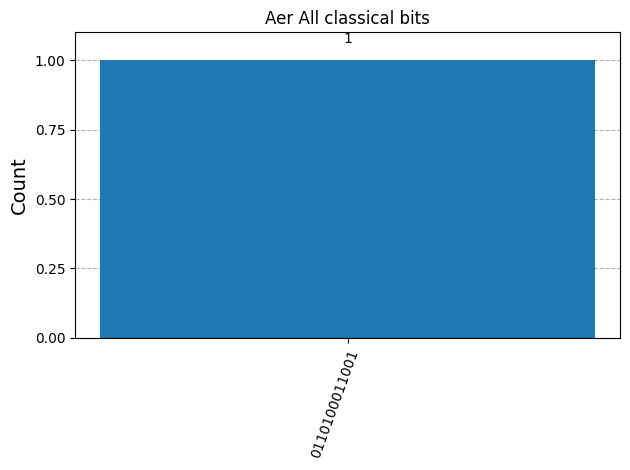

In [24]:
print("Aer All clbits counts:", counts)
plot_histogram(counts, title="Aer All classical bits")

Filtering Example

Truncated to final 2 bits: {'001': 1}


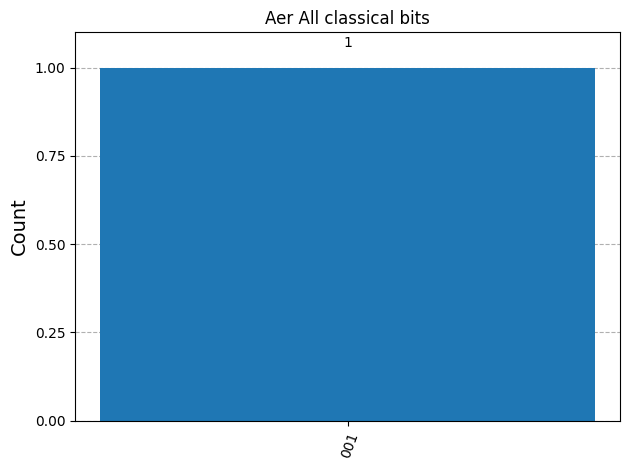

In [25]:
# Keep only the final measurement bits
final_counts = marginal_counts(counts, indices=range(N_q))

print("Truncated to final 2 bits:", final_counts)
plot_histogram(final_counts, title='Aer All classical bits')